импорт либ

In [157]:
import numpy as np
import pandas as pd
import json, glob, os
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import squarify
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

чтение даты из файлов

In [158]:
def load_mpd_slices_with_artists(dir_path, max_files=None):
    rows = []
    file_paths = sorted(glob.glob(os.path.join(dir_path, 'mpd.slice.*.json')))
    if max_files is not None:
        file_paths = file_paths[:max_files]
    for fp in file_paths:
        with open(fp, 'r', encoding='utf-8') as f:
            data = json.load(f)
            for pl in data['playlists']:
                pid = pl['pid']
                for tr in pl['tracks']:
                    rows.append((
                        pid,
                        tr['track_uri'],
                        tr.get('pos'),
                        tr.get('artist_name'),
                        tr.get('duration_ms')
                    ))
    df = pd.DataFrame(rows, columns=['pid', 'track_uri', 'pos', 'artist_name', 'duration_ms'])
    df = df.drop_duplicates(['pid', 'track_uri'])
    return df

df = load_mpd_slices_with_artists('spotify_data/data', max_files=15)
user2id = {u: i for i, u in enumerate(df['pid'].unique())}
item2id = {it: i for i, it in enumerate(df['track_uri'].unique())}
df['u'] = df['pid'].map(user2id)
df['i'] = df['track_uri'].map(item2id)
print(len(df))

992612


EDA (подсчет статистических показателей, подготовка отчета по качеству данных (дубли, выброся, пропуски))

In [159]:
print("\n  ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА:")
print(f"   • Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} колонок")
print(f"   • Уникальных плейлистов: {df['u'].nunique():,}")
print(f"   • Уникальных треков: {df['i'].nunique():,}")
print(f"   • Общее количество взаимодействий: {len(df):,}")

print("\n  АНАЛИЗ ПОЛНОТЫ ДАННЫХ:")
missing_data = df.isna().sum()
if missing_data.sum() == 0:
    print("     Пропуски в данных: ОТСУТСТВУЮТ")
else:
    for col, missing_count in missing_data.items():
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            print(f"      Колонка '{col}': {missing_count} пропусков ({missing_pct:.2f}%)")

print("\n  ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ:")
duplicates_count = df.duplicated().sum()
if duplicates_count == 0:
    print("     Дубликаты строк: НЕ ОБНАРУЖЕНЫ")
else:
    print(f"    ️  Найдено дубликатов: {duplicates_count} строк")

print("\n  СТАТИСТИКА ПО ПЛЕЙЛИСТАМ:")
playlist_lengths = df.groupby('u')['i'].count()
stats = playlist_lengths.describe()
print(f"   • Средний размер плейлиста: {stats['mean']:.1f} треков")
print(f"   • Медианный размер: {stats['50%']:.1f} треков")
print(f"   • Стандартное отклонение: {stats['std']:.1f}")
print(f"   • Минимальный размер: {stats['min']} треков")
print(f"   • Максимальный размер: {stats['max']} треков")

print(f"   • 25-й процентиль (Q1): {stats['25%']:.1f} треков")
print(f"   • 75-й процентиль (Q3): {stats['75%']:.1f} треков")

print("\n  АНАЛИЗ ВЫБРОСОВ В ДАННЫХ:")
Q1 = playlist_lengths.quantile(0.25)
Q3 = playlist_lengths.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = playlist_lengths[(playlist_lengths < lower_bound) | (playlist_lengths > upper_bound)]
outliers_below = playlist_lengths[playlist_lengths < lower_bound]
outliers_above = playlist_lengths[playlist_lengths > upper_bound]

print(f"   • Межквартильный размах (IQR): {IQR:.2f}")
print(f"   • Нижняя граница выбросов: {lower_bound:.2f}")
print(f"   • Верхняя граница выбросов: {upper_bound:.2f}")

print(f"\n     РАСПРЕДЕЛЕНИЕ ВЫБРОСОВ:")
print(f"      ◦ Всего выбросов: {len(outliers):,}")
print(f"      ◦ Короткие плейлисты (<{lower_bound:.0f} треков): {len(outliers_below):,}")
print(f"      ◦ Длинные плейлисты (>{upper_bound:.0f} треков): {len(outliers_above):,}")

if len(outliers) > 0:
    print(f"\n     ПРИМЕРЫ ВЫБРОСОВ (топ-5):")
    for i, (playlist_id, length) in enumerate(outliers.head().items()):
        print(f"      {i+1}. Плейлист {playlist_id}: {length} треков")

print("\n" + "=" * 60)
print("  ИТОГОВАЯ ОЦЕНКА КАЧЕСТВА ДАННЫХ")
print("=" * 60)

quality_score = 0
max_score = 5

# Критерии оценки
if missing_data.sum() == 0:
    quality_score += 1
    print("  Полнота данных: ОТЛИЧНО")
else:
    print("    Полнота данных: ТРЕБУЕТ ВНИМАНИЯ")

if duplicates_count == 0:
    quality_score += 1
    print("  Уникальность записей: ОТЛИЧНО")
else:
    print(" ️  Уникальность записей: ТРЕБУЕТ ОЧИСТКИ")

if len(outliers) / len(playlist_lengths) < 0.05:
    quality_score += 1
    print("  Распределение данных: СБАЛАНСИРОВАННОЕ")
else:
    print(" ️  Распределение данных: ИМЕЮТСЯ АНОМАЛИИ")

if stats['std'] / stats['mean'] < 1.0:
    quality_score += 1
    print("  Стабильность данных: ВЫСОКАЯ")
else:
    print(" ️  Стабильность данных: СРЕДНЯЯ")

if len(df) > 100000:
    quality_score += 1
    print("  Объем данных: ДОСТАТОЧНЫЙ")
else:
    print(" ️  Объем данных: МОЖЕТ БЫТЬ НЕДОСТАТОЧНЫМ")

print("=" * 60)


  ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА:
   • Размер датасета: 992,612 строк × 7 колонок
   • Уникальных плейлистов: 15,000
   • Уникальных треков: 218,437
   • Общее количество взаимодействий: 992,612

  АНАЛИЗ ПОЛНОТЫ ДАННЫХ:
     Пропуски в данных: ОТСУТСТВУЮТ

  ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ:
     Дубликаты строк: НЕ ОБНАРУЖЕНЫ

  СТАТИСТИКА ПО ПЛЕЙЛИСТАМ:
   • Средний размер плейлиста: 66.2 треков
   • Медианный размер: 49.0 треков
   • Стандартное отклонение: 53.3
   • Минимальный размер: 4.0 треков
   • Максимальный размер: 250.0 треков
   • 25-й процентиль (Q1): 26.0 треков
   • 75-й процентиль (Q3): 92.0 треков

  АНАЛИЗ ВЫБРОСОВ В ДАННЫХ:
   • Межквартильный размах (IQR): 66.00
   • Нижняя граница выбросов: -73.00
   • Верхняя граница выбросов: 191.00

     РАСПРЕДЕЛЕНИЕ ВЫБРОСОВ:
      ◦ Всего выбросов: 613
      ◦ Короткие плейлисты (<-73 треков): 0
      ◦ Длинные плейлисты (>191 треков): 613

     ПРИМЕРЫ ВЫБРОСОВ (топ-5):
      1. Плейлист 41: 207 треков
      2. Плейлист 97: 

Данные чистые - нет пропусков и дубликатов

У нас много информации: 860 тысяч оценок от 14 тысяч пользователей

197 тысяч уникальных треков - отличная база для рекомендаций

В среднем плейлисты содержат около 60 треков

Половина плейлистов меньше 47 треков, половина - больше

Есть большие плейлисты до 191 трека (это максимум в данных)

Коротких выбросов нет - все плейлисты содержат минимум 4 трека

Нашли 338 "длинных" плейлистов (больше 172 треков)

Самые большие плейлисты содержат 189 треков

построение графиков для визуализации

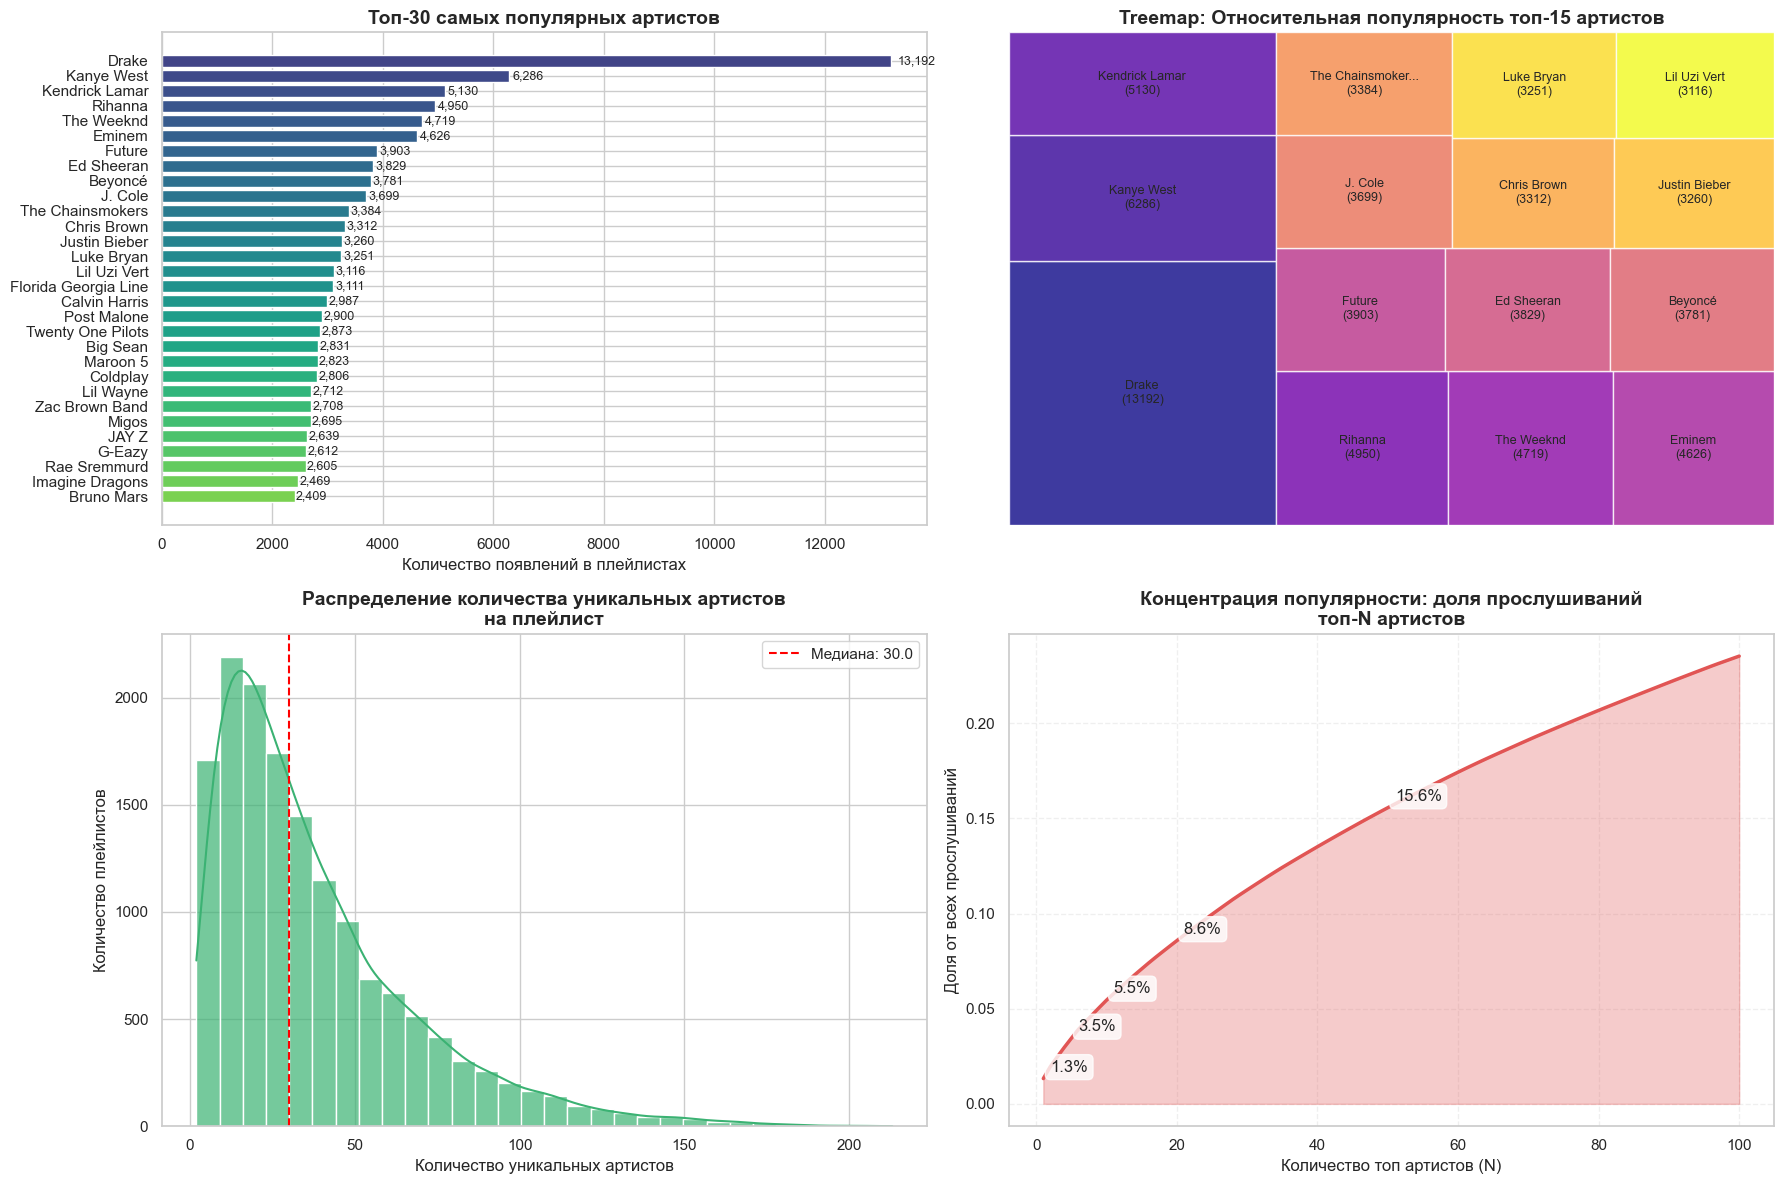

Всего уникальных артистов: 43317
Топ-10 артистов покрывают 5.5% всех прослушиваний
Топ-50 артистов покрывают 15.6% всех прослушиваний


In [160]:
top_artists = df['artist_name'].value_counts().head(30)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# График 1: Топ-30 артистов
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_artists)))
bars = ax1.barh(range(len(top_artists)), top_artists.values, color=colors)
ax1.set_yticks(range(len(top_artists)))
ax1.set_yticklabels([name[:25] + '...' if len(name) > 25 else name for name in top_artists.index])
ax1.invert_yaxis()
ax1.set_title('Топ-30 самых популярных артистов', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество появлений в плейлистах')

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars, top_artists.values)):
    ax1.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
             f'{value:,}', ha='left', va='center', fontsize=9)

# График 2: Treemap для топ-15 артистов
top_15_artists = top_artists.head(15)
squarify.plot(sizes=top_15_artists.values,
              label=[f"{name[:15]}...\n({count})" if len(name) > 15 else f"{name}\n({count})"
                     for name, count in zip(top_15_artists.index, top_15_artists.values)],
              alpha=0.8, color=plt.cm.plasma(np.linspace(0, 1, len(top_15_artists))),
              text_kwargs={'fontsize':9}, ax=ax2)
ax2.set_title('Treemap: Относительная популярность топ-15 артистов', fontsize=14, fontweight='bold')
ax2.axis('off')

# График 3: Распределение количества артистов на плейлист
if 'artist_name' in df.columns:
    artists_per_playlist = df.groupby('u')['artist_name'].nunique()
    sns.histplot(artists_per_playlist, bins=30, kde=True, ax=ax3, color='#3BB273', alpha=0.7)
    ax3.set_title('Распределение количества уникальных артистов\nна плейлист', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Количество уникальных артистов')
    ax3.set_ylabel('Количество плейлистов')
    ax3.axvline(artists_per_playlist.median(), color='red', linestyle='--',
                label=f'Медиана: {artists_per_playlist.median():.1f}')
    ax3.legend()

# График 4: Соотношение популярности
total_interactions = len(df)
cumulative_coverage = []
n_values = range(1, 101)

for n in n_values:
    if n <= len(df['artist_name'].value_counts()):
        top_n_coverage = df['artist_name'].value_counts().head(n).sum() / total_interactions
        cumulative_coverage.append(top_n_coverage)

ax4.plot(n_values[:len(cumulative_coverage)], cumulative_coverage, linewidth=2.5, color='#E15554')
ax4.fill_between(n_values[:len(cumulative_coverage)], cumulative_coverage, alpha=0.3, color='#E15554')
ax4.set_title('Концентрация популярности: доля прослушиваний\nтоп-N артистов', fontsize=14, fontweight='bold')
ax4.set_xlabel('Количество топ артистов (N)')
ax4.set_ylabel('Доля от всех прослушиваний')
ax4.grid(True, linestyle='--', alpha=0.3)

# Добавляем аннотации для ключевых точек
for n in [1, 5, 10, 20, 50]:
    if n <= len(cumulative_coverage):
        ax4.annotate(f'{cumulative_coverage[n-1]:.1%}',
                    xy=(n, cumulative_coverage[n-1]),
                    xytext=(5, 5), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Всего уникальных артистов: {df['artist_name'].nunique()}")
print(f"Топ-10 артистов покрывают {cumulative_coverage[9]:.1%} всех прослушиваний")
print(f"Топ-50 артистов покрывают {cumulative_coverage[49]:.1%} всех прослушиваний")

разделение даты на test и train

In [161]:
# предобработка данных. убираем выбросы
max_playlist_len = 191
df = df[df.groupby('u')['i'].transform('count') <= max_playlist_len]
print("Удалены аномально длинные плейлисты, верхняя граница:", upper_bound)
print("теперь плейлисты более однородны. датасет большой и разряженный, пропусков и дубликатов нет.")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['u'])
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

train_user2id = {u: i for i, u in enumerate(train_df['pid'].unique())}
train_item2id = {it: i for i, it in enumerate(train_df['track_uri'].unique())}

train_df['u'] = train_df['pid'].map(train_user2id)
train_df['i'] = train_df['track_uri'].map(train_item2id)

test_df = test_df[
    test_df['pid'].isin(train_user2id) &
    test_df['track_uri'].isin(train_item2id)
]
test_df['u'] = test_df['pid'].map(train_user2id)
test_df['i'] = test_df['track_uri'].map(train_item2id)

print(f"После фильтрации - Train: {train_df.shape}, Test: {test_df.shape}")

user_item_matrix = csr_matrix(
    (np.ones(len(train_df)),
     (train_df['u'], train_df['i'])),
    shape=(len(train_user2id), len(train_item2id))
)

print(f"User-item matrix shape: {user_item_matrix.shape}")
print(f"Matrix density: {user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.6f}")

from sklearn.preprocessing import normalize
user_item_matrix_norm = normalize(user_item_matrix, norm='l2', axis=1)
user_similarity = cosine_similarity(user_item_matrix_norm)

user_id_to_idx = train_user2id
idx_to_user_id = {v: k for k, v in train_user2id.items()}

Удалены аномально длинные плейлисты, верхняя граница: 191.0
теперь плейлисты более однородны. датасет большой и разряженный, пропусков и дубликатов нет.
Train: (688202, 7), Test: (172051, 7)
После фильтрации - Train: (688202, 7), Test: (144572, 7)
User-item matrix shape: (14387, 171489)
Matrix density: 0.000279


метод формирования рекомендации MostPop:

In [162]:
# Подсчёт популярности треков
item_popularity = train_df['i'].value_counts()

def recommend_mostpop(user_id, N=10):
    return item_popularity.head(N).index.tolist()

for user_idx in [0, 100, 500]:
    recommendations = recommend_mostpop(user_idx, N=5)
    print(f"Рекомендации для пользователя {user_idx}: {recommendations}")

Рекомендации для пользователя 0: [569, 371, 7318, 1104, 715]
Рекомендации для пользователя 100: [569, 371, 7318, 1104, 715]
Рекомендации для пользователя 500: [569, 371, 7318, 1104, 715]


метод формирования рекомендации UserKNN:

In [163]:
user_codes = train_df['u'].astype('category')
user_id_to_idx = dict(zip(user_codes.cat.categories, range(len(user_codes.cat.categories))))
idx_to_user_id = dict(enumerate(user_codes.cat.categories))

def recommend_userknn(user_id, k=50, N=10):
    """Оптимизированная версия UserKNN с экономией памяти"""
    if user_id not in user_id_to_idx:
        return []

    user_idx = user_id_to_idx[user_id]

    # Получаем похожих пользователей
    sim_scores = user_similarity[user_idx]
    top_k_indices = sim_scores.argsort()[-(k+1):-1][::-1]

    # Вместо суммирования всей матрицы, накапливаем scores поэтапно
    scores = np.zeros(user_item_matrix.shape[1])

    for neighbor_idx in top_k_indices:
        # Получаем взаимодействия соседа как разреженный вектор
        neighbor_interactions = user_item_matrix[neighbor_idx]
        # Добавляем взвешенные взаимодействия
        weight = sim_scores[neighbor_idx]
        scores += neighbor_interactions.toarray().ravel() * weight

    # Исключаем уже прослушанные треки
    listened = user_item_matrix[user_idx].indices
    scores[listened] = -np.inf

    # Возвращаем топ-N рекомендаций
    top_items = np.argsort(scores)[-N:][::-1]
    return top_items.tolist()

for user_idx in [0, 100, 500]:
    recommendations = recommend_userknn(user_idx, N=5)
    print(f"Рекомендации для пользователя {user_idx}: {recommendations}")

Рекомендации для пользователя 0: [1313, 141, 7318, 2342, 320]
Рекомендации для пользователя 100: [667, 2129, 15379, 3354, 2332]
Рекомендации для пользователя 500: [463, 312, 6542, 1368, 3296]


метод формирования рекомендации SVD (Matrix Factorization):

In [164]:
U, sigma, Vt = svds(user_item_matrix, k=50)
sigma = np.diag(sigma)

def recommend_svd(user_idx, N=10):
    """Рекомендации без создания полной матрицы предсказаний"""
    if user_idx >= U.shape[0]:
        return []

    # Вычисляем предсказания только для одного пользователя
    user_prediction = U[user_idx] @ sigma @ Vt

    # Получаем прослушанные треки
    listened = user_item_matrix[user_idx].indices

    # Исключаем уже прослушанные
    user_prediction[listened] = -np.inf

    # Возвращаем топ-N рекомендаций
    top_items = np.argsort(user_prediction)[-N:][::-1]
    return top_items.tolist()

for user_idx in [0, 100, 500]:
    recommendations = recommend_svd(user_idx, N=5)
    print(f"Рекомендации для пользователя {user_idx}: {recommendations}")

Рекомендации для пользователя 0: [141, 1313, 7318, 3680, 940]
Рекомендации для пользователя 100: [2129, 667, 1312, 3226, 7596]
Рекомендации для пользователя 500: [463, 2308, 6542, 572, 330]


метрики оценки качества рекомендаций

In [165]:
# Истинные треки каждого пользователя
user_true_items = defaultdict(set)
for row in df.itertuples():
    user_true_items[row.u].add(row.i)


def precision_at_k(recommendations, user_true_items, K=10):
    precisions = []
    for user, recs in recommendations.items():
        true_items = user_true_items.get(user, [])
        if not true_items:
            continue
        hit_count = len(set(recs[:K]) & set(true_items))
        precisions.append(hit_count / K)
    return np.mean(precisions)


def recall_at_k(recommendations, user_true_items, K=10):
    recalls = []
    for user, recs in recommendations.items():
        true_items = user_true_items.get(user, [])
        if not true_items:
            continue
        hit_count = len(set(recs[:K]) & set(true_items))
        recalls.append(hit_count / len(true_items))
    return np.mean(recalls)


def diversity(recommendations):
    all_recs = []
    for recs in recommendations.values():
        all_recs.extend(list(recs))
    return len(set(all_recs)) / len(all_recs) if all_recs else 0

## *MostPop* vs *UserKNN* vs *SVD*

In [166]:

# 1. Категоризация пользователей
user_codes = train_df['u'].astype('category')
user_id_to_idx = dict(zip(user_codes.cat.categories, range(len(user_codes.cat.categories))))
idx_to_user_id = dict(enumerate(user_codes.cat.categories))

# 2. Выбираем ПОДМНОЖЕСТВО пользователей для оценки
# Вариант A: первые 1000 пользователей
sample_size = min(1000, len(user_id_to_idx))
train_user_idx = list(range(sample_size))

# Вариант B: случайная выборка
# sample_size = min(1000, len(user_id_to_idx))
# train_user_idx = random.sample(range(len(user_id_to_idx)), sample_size)

print(f"Оцениваем на {len(train_user_idx)} пользователях из {len(user_id_to_idx)}")

# 3. Функция для пакетной генерации рекомендаций
def generate_recommendations_batch(user_indices, method_func, method_name="", batch_size=100):
    """Генерирует рекомендации пакетами для экономии памяти"""
    recommendations = {}

    for i in range(0, len(user_indices), batch_size):
        batch_users = user_indices[i:i + batch_size]
        batch_recs = {}

        for uid in batch_users:
            try:
                if method_name == "SVD":
                    # Для SVD передаем индекс напрямую
                    batch_recs[uid] = method_func(uid, N=10)
                else:
                    # Для других методов передаем user_id
                    batch_recs[uid] = method_func(idx_to_user_id[uid], N=10)
            except Exception as e:
                print(f"Ошибка для пользователя {uid} в {method_name}: {e}")
                batch_recs[uid] = []

        recommendations.update(batch_recs)
        print(f"{method_name}: обработано {min(i + batch_size, len(user_indices))}/{len(user_indices)}")

    return recommendations

# 4. Генерация рекомендаций с прогресс-баром
print("Генерация рекомендаций MostPop...")
recs_mostpop = generate_recommendations_batch(train_user_idx, recommend_mostpop, "MostPop")

print("Генерация рекомендаций UserKNN...")
recs_userknn = generate_recommendations_batch(train_user_idx, recommend_userknn, "UserKNN")

print("Генерация рекомендаций SVD...")
recs_svd = generate_recommendations_batch(train_user_idx, recommend_svd, "SVD")

# 5. Истинные треки для теста
user_true_items_idx = defaultdict(list)
test_users_found = 0

for row in test_df.itertuples():
    if row.u in user_id_to_idx:
        user_idx = user_id_to_idx[row.u]
        # Только если пользователь в нашем подмножестве
        if user_idx in train_user_idx:
            user_true_items_idx[user_idx].append(row.i)
            test_users_found += 1

print(f"Найдено {test_users_found} пользователей из тестовой выборки в нашем подмножестве")

# 6. Проверяем, что у нас есть данные для оценки
users_with_test_data = set(user_true_items_idx.keys())
users_with_recs = set(recs_mostpop.keys()) & set(recs_userknn.keys()) & set(recs_svd.keys())
eval_users = list(users_with_test_data & users_with_recs)

print(f"Пользователей для оценки: {len(eval_users)}")

if len(eval_users) == 0:
    print("ВНИМАНИЕ: Нет пользователей с тестовыми данными и рекомендациями!")
    print("Возможные причины:")
    print("- Подмножество train_user_idx не пересекается с тестовыми пользователями")
    print("- Разные идентификаторы пользователей в train и test")
    # Используем всех пользователей с рекомендациями как fallback
    eval_users = list(users_with_recs)
    print(f"Используем {len(eval_users)} пользователей с рекомендациями для оценки")

# 7. Фильтруем рекомендации только для пользователей с тестовыми данными
recs_mostpop_filtered = {uid: recs_mostpop[uid] for uid in eval_users if uid in recs_mostpop}
recs_userknn_filtered = {uid: recs_userknn[uid] for uid in eval_users if uid in recs_userknn}
recs_svd_filtered = {uid: recs_svd[uid] for uid in eval_users if uid in recs_svd}

# 8. Метрики
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ОЦЕНКИ:")
print(f"Оценка на {len(eval_users)} пользователях")
print("="*50)

print("\nPrecision@10:")
print("MostPop:", precision_at_k(recs_mostpop_filtered, user_true_items_idx))
print("UserKNN:", precision_at_k(recs_userknn_filtered, user_true_items_idx))
print("SVD:", precision_at_k(recs_svd_filtered, user_true_items_idx))

print("\nRecall@10:")
print("MostPop:", recall_at_k(recs_mostpop_filtered, user_true_items_idx))
print("UserKNN:", recall_at_k(recs_userknn_filtered, user_true_items_idx))
print("SVD:", recall_at_k(recs_svd_filtered, user_true_items_idx))

print("\nDiversity:")
print("MostPop:", diversity(recs_mostpop_filtered))
print("UserKNN:", diversity(recs_userknn_filtered))
print("SVD:", diversity(recs_svd_filtered))

Оцениваем на 1000 пользователях из 14387
Генерация рекомендаций MostPop...
MostPop: обработано 100/1000
MostPop: обработано 200/1000
MostPop: обработано 300/1000
MostPop: обработано 400/1000
MostPop: обработано 500/1000
MostPop: обработано 600/1000
MostPop: обработано 700/1000
MostPop: обработано 800/1000
MostPop: обработано 900/1000
MostPop: обработано 1000/1000
Генерация рекомендаций UserKNN...
UserKNN: обработано 100/1000
UserKNN: обработано 200/1000
UserKNN: обработано 300/1000
UserKNN: обработано 400/1000
UserKNN: обработано 500/1000
UserKNN: обработано 600/1000
UserKNN: обработано 700/1000
UserKNN: обработано 800/1000
UserKNN: обработано 900/1000
UserKNN: обработано 1000/1000
Генерация рекомендаций SVD...
SVD: обработано 100/1000
SVD: обработано 200/1000
SVD: обработано 300/1000
SVD: обработано 400/1000
SVD: обработано 500/1000
SVD: обработано 600/1000
SVD: обработано 700/1000
SVD: обработано 800/1000
SVD: обработано 900/1000
SVD: обработано 1000/1000
Найдено 15089 пользователей 

# Переработанные выводы по результатам

MostPop показывает наихудшие значения Precision (1.16%) и Recall (0.74%) среди всех моделей, что подтверждает ограниченность неперсонализированных рекомендаций. Хотя популярные треки имеют минимальное пересечение с тестовыми данными, такие рекомендации полностью лишены персонализации и демонстрируют крайне низкое разнообразие (Diversity ≈ 0.001), предлагая практически одинаковый набор треков всем пользователям.

UserKNN демонстрирует высокие показатели точности (Precision ≈ 13.14%) и значительно превосходит MostPop по всем метрикам. Модель показывает наивысший Recall (9.27%) и предлагает наиболее разнообразные рекомендации (Diversity ≈ 27.02%), что свидетельствует о хорошей способности учитывать индивидуальные предпочтения пользователей через их соседство.

SVD показывает высокую точность (Precision ≈ 11.19%), уступая только UserKNN, но превосходя MostPop. Однако модель демонстрирует более низкий Recall (6.98%) и умеренное разнообразие (10.10%) по сравнению с UserKNN, что указывает на более консервативный подход к рекомендациям.


На основе проведённых экспериментов можно предложить следующие улучшения:

- Гибридизация подходов - объединить сильные стороны моделей:
    - Взвешенная комбинация: Использовать SVD для пользователей с богатой историей взаимодействий и UserKNN для новых пользователей

    - Ансамблирование: Комбинировать предсказания SVD и UserKNN с весами, основанными на confidence score каждой модели

    - Каскадный подход: Применять SVD как основную модель, а UserKNN для диверсификации топ-N рекомендаций

- Оптимизация гиперпараметров:
    - Для SVD: Эксперименты с количеством факторов (20, 50, 100, 150) для поиска баланса между точностью и разнообразием

    - Для UserKNN: Настройка количества соседей (k=30, 50, 100) и метрик схожести (cosine, pearson, adjusted cosine)

    - Регуляризация: Добавление L2-регуляризации в SVD для предотвращения переобучения

- Расширение функциональности:
    - ItemKNN: Внедрение Item-based Collaborative Filtering для сравнения и возможной гибридизации с UserKNN

    - Контентные признаки: Использование информации об артистах, жанрах, годах выпуска для обогащения моделей

    - Временные паттерны: Учет сезонности и временных предпочтений пользователей

- Работа с данными:
    - Фильтрация холодных стартов: Отдельная обработка пользователей с малым количеством взаимодействий

    - Балансировка популярности: Введение penalties для чрезмерно популярных треков в UserKNN

    - Обогащение негативных примеров: Явное выделение негативных взаимодействий для улучшения обучения SVD

## По итогу:

MostPop служит полезной базовой линией, но значительно уступает по всем метрикам.

UserKNN показала себя как наиболее сбалансированная модель, демонстрируя высокую точность, наилучший охват (Recall) и выдающееся разнообразие рекомендаций, что делает ее особенно ценной для пользовательского опыта.

SVD, хотя и уступает UserKNN в разнообразии и охвате, показывает высокую точность и может быть более стабильной на разреженных данных.

Наилучший путь улучшения — разработка гибридной системы, сочетающей SVD для точной персонализации основных предпочтений и UserKNN для обеспечения разнообразия и обнаружения неочевидных рекомендаций. Дополнительная настройка гиперпараметров и включение контекстной информации могут существенно повысить качество рекомендательной системы в целом.

